# Figure 1 of Pierard2024TheTile: Graphical Abstract

In [1]:
from sorbetto.annotation import AnnotationText
from sorbetto.ranking import RankingScore
from sorbetto.tile import Tile
from sorbetto.parameterization import ParameterizationDefault

import matplotlib.pyplot as plt

In [2]:
# To start with, choose the class priors you want.
prior_pos = 0.25

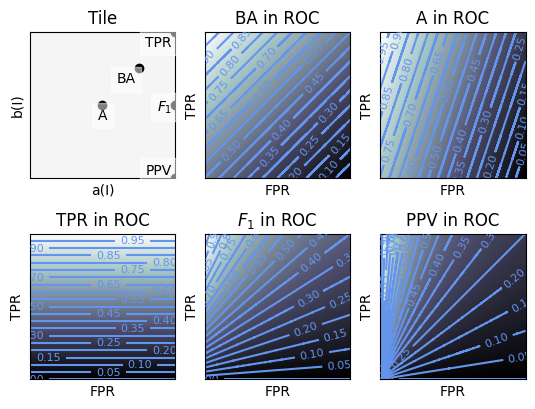

In [3]:
figure, axis = plt.subplots(2, 3)

scores = [
    RankingScore.getBalancedAccuracy ( prior_pos ),
    RankingScore.getAccuracy (),
    RankingScore.getTruePositiveRate (),
    RankingScore.getF ( beta=1.0 ),
    RankingScore.getPositivePredictiveValue ()
]

for i, score in enumerate ( scores ) :
    ax = axis[(i+1)//3, (i+1)%3]
    score.drawInROC ( figure, ax, prior_pos, show_colorbar=False, show_no_skills=False, show_priors=False, show_unbiased=False, show_opposite_unbiased=False )
    ax.set_title ( '{} in ROC'.format ( score.shortLabel ) )
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')

ax = axis[0, 0]
parameterization = ParameterizationDefault()
tile = Tile ( parameterization )
for score in scores :
    annotation = AnnotationText ( score, color='k' )
    tile.appendAnnotation ( annotation )
tile.draw (fig=figure, ax=ax)
ax.set_xticks([])
ax.set_yticks([])

plt.show ()
